# CIFAR-10 FCN
The goal of this model is to use CIFAR-10 to solve image classification problems.  
This model uses Fully Convolutional Networks (FCN).

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers
from tensorflow.keras.datasets import cifar10

import numpy as np
import matplotlib.pyplot as plt

from keras import backend as K
print(K.backend())

I0000 00:00:1774616891.638360   21559 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


tensorflow


In [2]:
from keras.layers import Input, Flatten, Dense

model = keras.models.Sequential([
    Input(shape=(32, 32, 3)),
    Flatten(),
    Dense(256, activation="relu"),
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

I0000 00:00:1774616894.145561   21559 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [3]:
from tensorflow.keras.utils import to_categorical
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

x_train, x_test = x_train / 255, x_test / 255

print(x_train.shape)
print(y_train.shape)

/home/juhana/anaconda3_v2/envs/keras/lib/python3.11/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


(50000, 32, 32, 3)
(50000, 10)


In [4]:
model.compile(
    loss="categorical_crossentropy",
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

In [5]:
history = model.fit(x_train, y_train, batch_size=32, epochs=10, validation_split=0.2)

W0000 00:00:1774616897.920079   21559 cpu_allocator_impl.cc:82] Allocation of 491520000 exceeds 10% of free system memory.
W0000 00:00:1774616898.807239   21559 cpu_allocator_impl.cc:82] Allocation of 491520000 exceeds 10% of free system memory.


Epoch 1/10


I0000 00:00:1774616899.647460   21619 service.cc:153] XLA service 0x753348032210 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774616899.647494   21619 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 12.8.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1774616899.675267   21619 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774616899.817569   21619 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1774616899.826668   21619 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1607__.18
I0000 00:00:1774616901.486909   21619 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set i

  28/1250 ━━━━━━━━━━━━━━━━━━━━ 15:36 766ms/step - accuracy: 0.1162 - loss: 2.5390

I0000 00:00:1774616903.821929   21619 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.3186 - loss: 1.8705 - val_accuracy: 0.3661 - val_loss: 1.7541
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3920 - loss: 1.6934 - val_accuracy: 0.3921 - val_loss: 1.6925
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4206 - loss: 1.6134 - val_accuracy: 0.4057 - val_loss: 1.6553
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4399 - loss: 1.5663 - val_accuracy: 0.4208 - val_loss: 1.6267
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4500 - loss: 1.5254 - val_accuracy: 0.4441 - val_loss: 1.5693
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4618 - loss: 1.4958 - val_accuracy: 0.4577 - val_loss: 1.5352
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4734 - loss: 1.4711 - val_accuracy: 0.4579 - val_loss: 1.5457
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4795 - loss: 1.4448 - val_accura

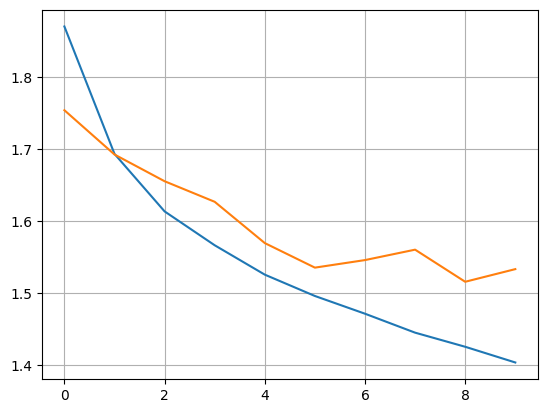

In [6]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.grid()
plt.show()